# 02 - Exploratory Data Analysis

**Author:** Juan Ruelas  
**Date:** 2026-05

Goals for this notebook:

1. Merge the load and weather series on timestamp and confirm the join is clean.
2. Visualize multi-year, weekly, and intraday seasonality - these will drive feature engineering.
3. Quantify load-weather relationships via a correlation heatmap.
4. Check autocorrelation structure (ACF/PACF) to motivate lag features and validate that a non-stationary, seasonal model is appropriate.
5. Persist the merged frame to `../data/processed/merged.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid')

raw_dir       = Path('..') / 'data' / 'raw'
processed_dir = Path('..') / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

## 1. Load and merge raw data

An inner join on `timestamp` guarantees that every retained row has both load and weather observations. Any rare gap on either side is simply dropped - we prefer a clean panel to imputation in this first pass.

In [2]:
load    = pd.read_csv(raw_dir / 'germany_load.csv',  parse_dates=['timestamp'])
weather = pd.read_csv(raw_dir / 'berlin_weather.csv', parse_dates=['timestamp'])

df = load.merge(weather, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
print('merged shape:', df.shape)
print('date range  :', df['timestamp'].min(), '->', df['timestamp'].max())
df.head()

merged shape: (43824, 6)
date range  : 2015-01-01 00:00:00 -> 2019-12-31 23:00:00


,timestamp,load_mw,temperature_2m,relative_humidity_2m,wind_speed_10m,direct_radiation
0,2015-01-01 00:00:00,41151.0,3.8,96,14.4,0.0
1,2015-01-01 01:00:00,40135.0,3.6,95,14.9,0.0
2,2015-01-01 02:00:00,39106.0,3.3,94,14.6,0.0
3,2015-01-01 03:00:00,38765.0,3.0,94,14.1,0.0
4,2015-01-01 04:00:00,38941.0,2.3,94,13.0,0.0


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,43824,2017-07-01 23:30:00,2015-01-01 00:00:00,2016-04-01 11:45:00,2017-07-01 23:30:00,2018-10-01 11:15:00,2019-12-31 23:00:00,NaN
load_mw,43824.0,55859.295044,31307.0,47432.0,55467.0,64788.25,77549.0,10005.61985
temperature_2m,43824.0,10.772353,-12.8,4.3,10.1,17.0,37.3,8.267074
relative_humidity_2m,43824.0,74.279025,14.0,62.0,78.0,89.0,100.0,17.657785
wind_speed_10m,43824.0,13.280707,0.0,8.4,12.3,17.1,60.2,6.336322
direct_radiation,43824.0,74.742265,0.0,0.0,0.0,74.0,767.0,143.995973


## 2. Full load series

We expect a strong annual cycle - higher winter demand from electric heating and lighting - plus a smaller summer hump for AC.

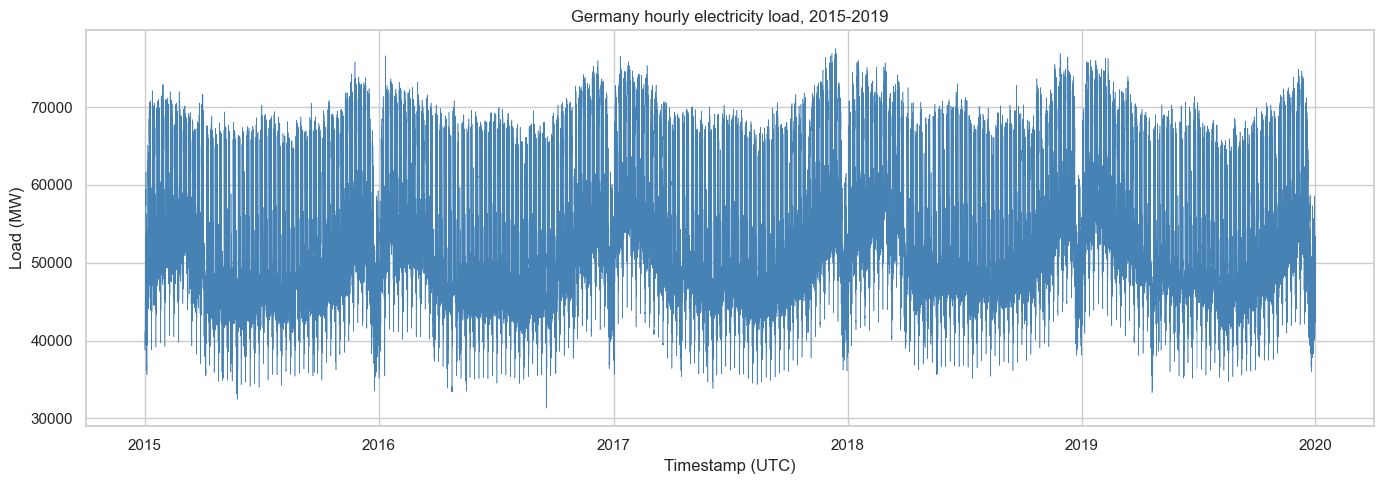

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'], df['load_mw'], linewidth=0.4, color='steelblue')
ax.set_title('Germany hourly electricity load, 2015-2019')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Load (MW)')
plt.tight_layout()
plt.show()

*Observation.* The series is clearly non-stationary in mean - winter peaks around 75-80 GW vs summer troughs near 45-50 GW - and shows the expected high-frequency intraday cycle riding on top of the annual envelope.

## 3. Seasonal decomposition

We use an additive STL-style decomposition with a weekly period (168 hours) on a downsampled daily mean to keep the plot legible. Hourly decomposition with `period=8760` is technically possible but extremely slow and visually dense.

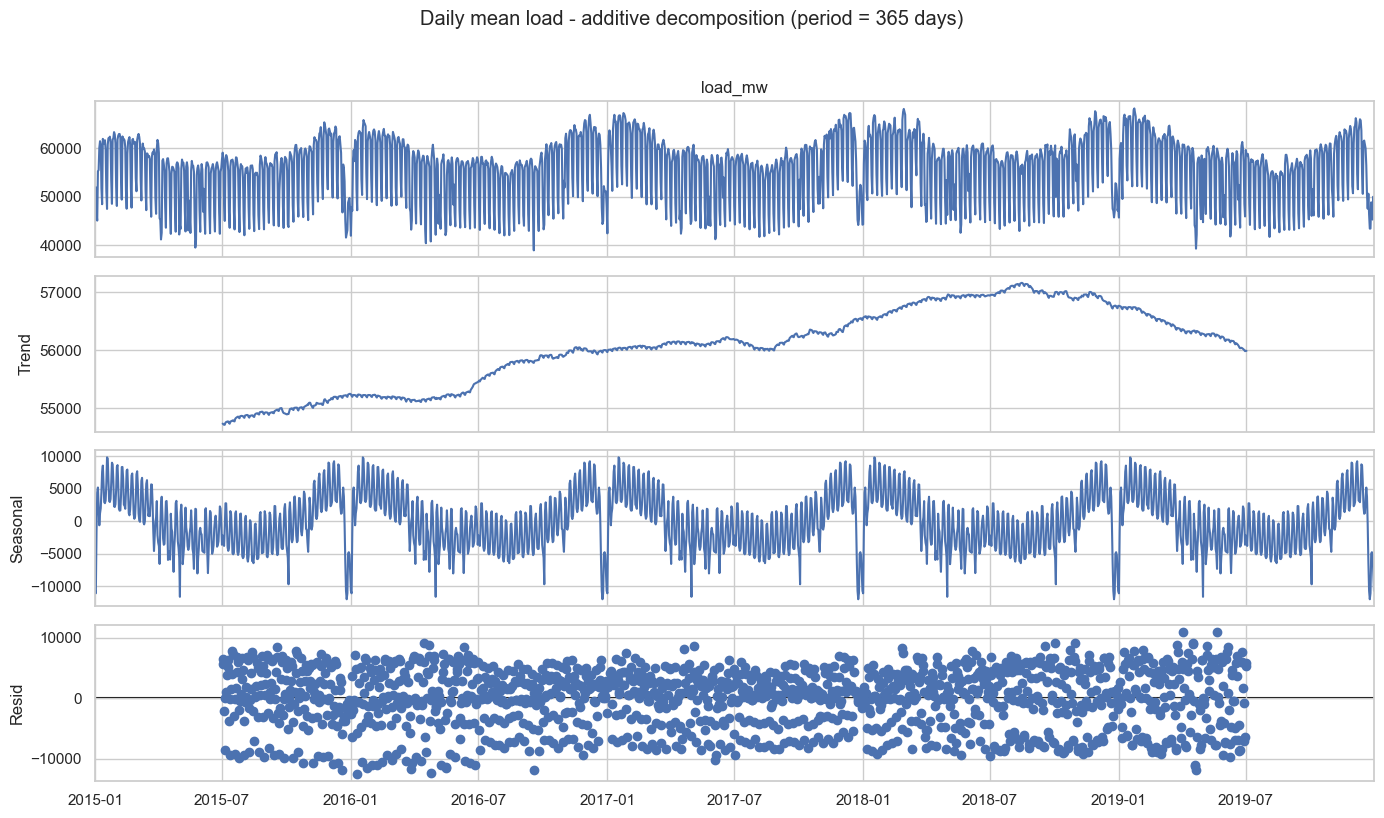

In [5]:
daily = df.set_index('timestamp')['load_mw'].resample('D').mean()
decomp = seasonal_decompose(daily.dropna(), model='additive', period=365)

fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Daily mean load - additive decomposition (period = 365 days)', y=1.02)
plt.tight_layout()
plt.show()

*Observation.* Trend is essentially flat over 2015-2019, confirming demand growth has been negligible in this period. The seasonal component is dominated by a clean sinusoidal winter-summer swing of roughly +/- 8-10 GW, and residuals look reasonably homoscedastic.

## 4. Weekly and intraday patterns

These two views motivate the calendar features we will add in notebook 03.

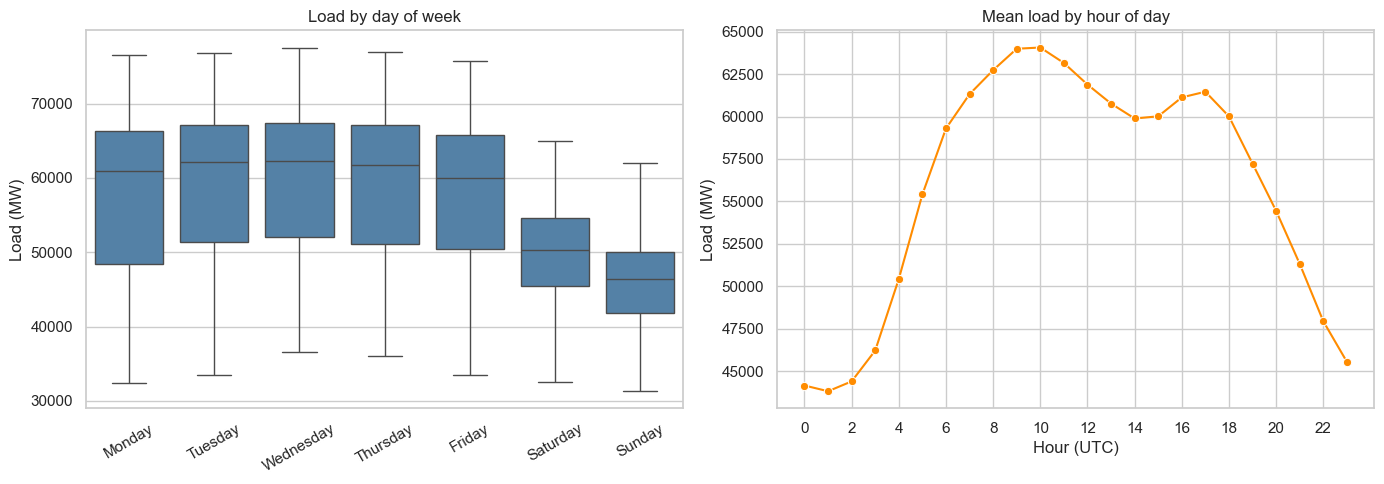

In [6]:
df['hour'] = df['timestamp'].dt.hour
df['dow'] = df['timestamp'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x='dow', y='load_mw', order=dow_order, ax=axes[0], color='steelblue',
    showfliers=False,
)
axes[0].set_title('Load by day of week')
axes[0].set_xlabel('')
axes[0].set_ylabel('Load (MW)')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(
    data=df.groupby('hour')['load_mw'].mean().reset_index(),
    x='hour', y='load_mw', ax=axes[1], color='darkorange', marker='o',
)
axes[1].set_title('Mean load by hour of day')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Load (MW)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

*Observation.* Weekday-vs-weekend separation is ~10 GW (industry shuts down on weekends). The hourly profile is the textbook two-peak pattern - a morning ramp around 06-08 UTC and an evening peak around 17-19 UTC, with a deep overnight trough.

## 5. Correlation between load and weather

Pearson correlation is enough for a first scan; the relationship between temperature and load is well known to be non-linear and U-shaped, so we will not over-interpret the linear coefficient.

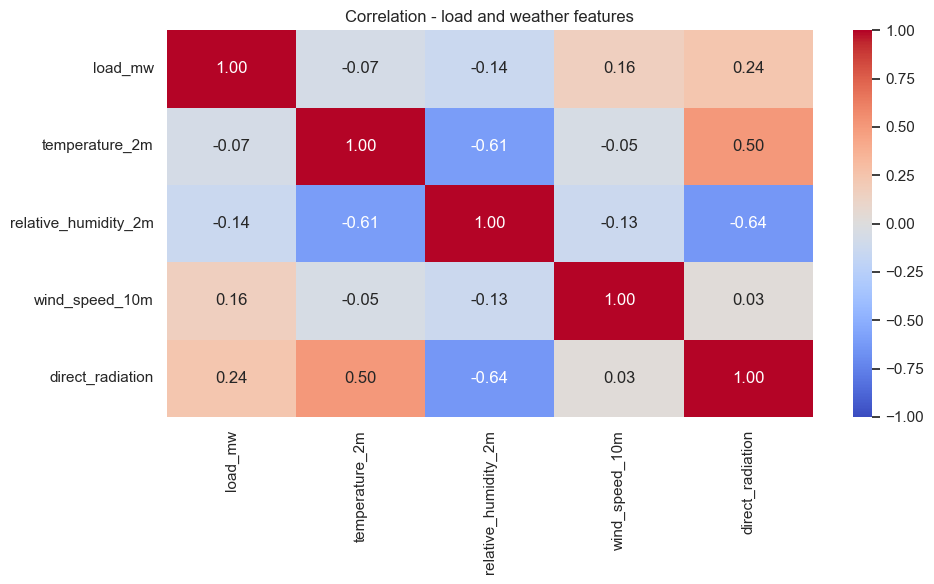

In [7]:
weather_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'direct_radiation']
corr = df[['load_mw', *weather_cols]].corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation - load and weather features')
plt.tight_layout()
plt.show()

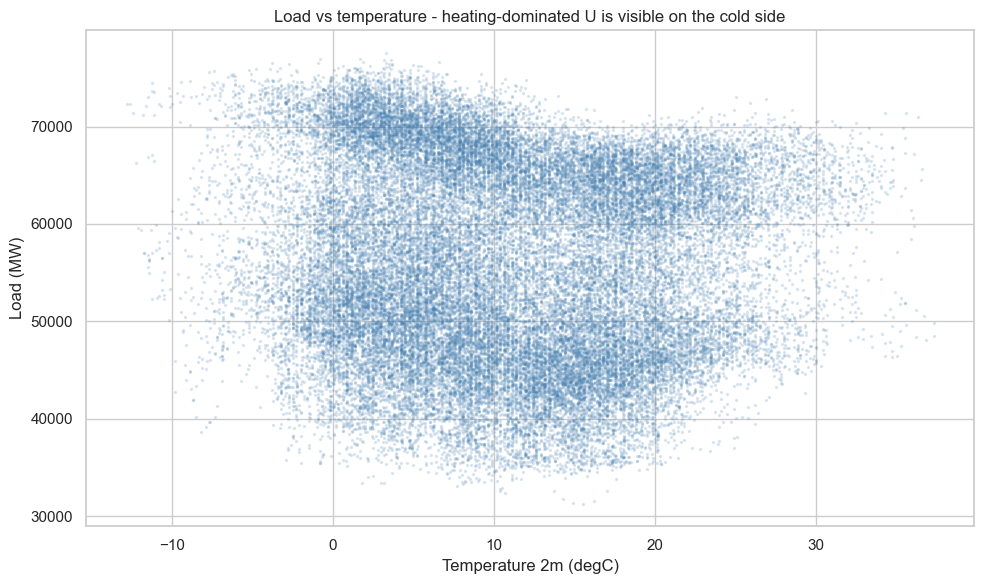

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['temperature_2m'], df['load_mw'], s=2, alpha=0.15, color='steelblue')
ax.set_xlabel('Temperature 2m (degC)')
ax.set_ylabel('Load (MW)')
ax.set_title('Load vs temperature - heating-dominated U is visible on the cold side')
plt.tight_layout()
plt.show()

*Observation.* The linear correlation between load and temperature is negative (cold -> more demand) but moderate (~ -0.45) because the relationship saturates and turns slightly positive above ~22 degC. A tree-based model will capture this non-linearity natively.

## 6. ACF / PACF

We expect very strong lag-1, lag-24 (daily), and lag-168 (weekly) autocorrelation. The PACF after differencing should drop off after a small number of lags, suggesting that lag features will be highly informative.

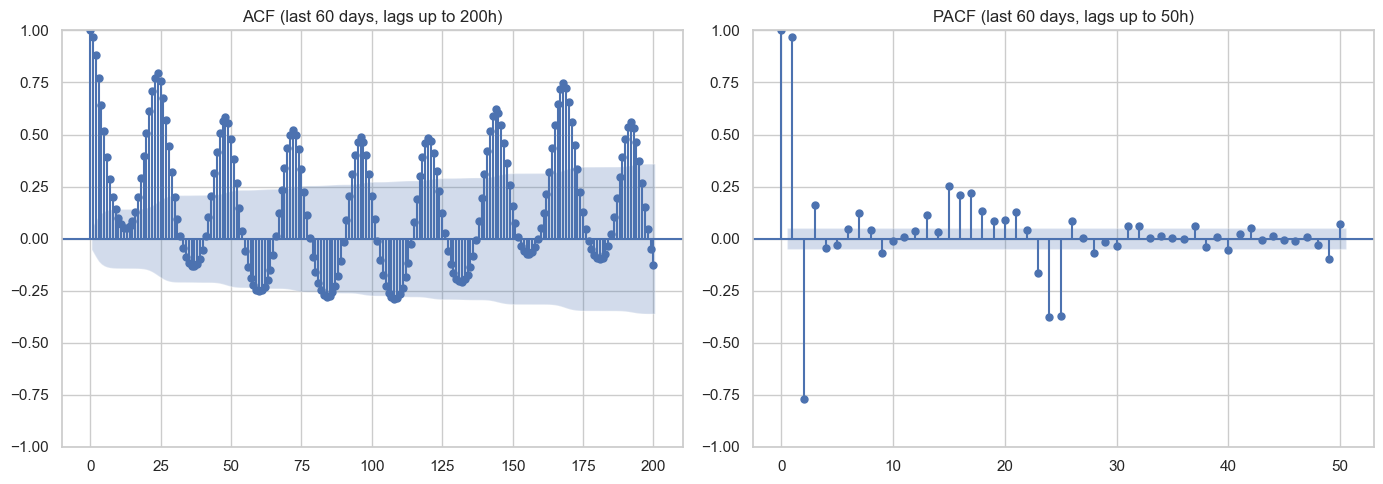

In [9]:
sample = df['load_mw'].iloc[-24 * 60:]  # last ~60 days for fast plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(sample, lags=200, ax=axes[0])
axes[0].set_title('ACF (last 60 days, lags up to 200h)')
plot_pacf(sample, lags=50, ax=axes[1], method='ywm')
axes[1].set_title('PACF (last 60 days, lags up to 50h)')
plt.tight_layout()
plt.show()

*Observation.* ACF spikes at lags 24, 48, ..., 168 are textbook daily-plus-weekly seasonality. PACF dies off after a handful of lags once daily structure is accounted for - good news for lag-feature engineering.

## 7. Persist merged frame

In [10]:
merged_path = processed_dir / 'merged.csv'
df.drop(columns=['hour', 'dow']).to_csv(merged_path, index=False)
print('saved to', merged_path)
print('rows:', len(df))

saved to ..\data\processed\merged.csv
rows: 43824


**Takeaways for modelling.**

- Daily (24h) and weekly (168h) seasonality dominate - we need at minimum 1, 24, 168h lags.
- Calendar effects (weekday vs weekend, holidays) explain a chunk of variance independently of weather.
- Temperature carries useful but non-linear information - tree models will use it best; Prophet will need it as an extra regressor.
- The series is mean-stationary year-over-year, so a 4-train-1-test (2015-2018 vs 2019) split is fair.